# 🧹 HR Analytics — Data Preprocessing & Cleaning Notebook
**Dataset**: Human Resources Employee Data (1,530 records, 18 features)  
**Goal**: Clean, validate, and engineer features for the Streamlit ML Dashboard  
**Business Context**: Predict employee attrition, analyze engagement, and optimize retention strategies.


## 1. Setup & Imports

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Raw Data

In [8]:
df_raw = pd.read_csv('data\hr_raw_data.csv')
print(f"Shape: {df_raw.shape}")
display(df_raw.head())

Shape: (1530, 18)


,employee_id,name,age,gender,department,position,education,years_at_company,salary,performance_score,satisfaction_score,training_hours,projects_completed,absences_days,attrition,hire_date,city,remote_work
0,EMP0001,James Robinson II,60.00,F,Legal,Junior,PhD,1.00,122284.70,4.00,5,NaN,21,5,0,2010-02-04,Port Amychester,1
1,EMP0002,Andrea Romero,50.00,Male,Engineering,Senior,Bachelor,13.00,63447.60,4.00,4,49.00,10,9,0,2020-02-10,Richardland,1
2,EMP0003,Jane Prince,36.00,Male,IT,Manager,PhD,1.00,73850.75,4.00,3,67.00,9,7,0,2023-07-15,Longshire,1
3,EMP0004,Cassandra French,29.00,F,Operations,Manager,Master,3.00,46333.38,3.00,2,80.00,16,16,1,2021-10-01,Rachelview,1
4,EMP0005,Kristi Rich,42.00,Non-binary,Finance,Mid-level,Bachelor,16.00,75137.31,5.00,5,NaN,13,24,0,2023-01-27,Derrickborough,0


In [9]:
print("=== Data Types ===")
print(df_raw.dtypes)
print("\n=== Missing Values ===")
missing = df_raw.isnull().sum()
print(missing[missing > 0])

=== Data Types ===
employee_id               str
name                      str
age                   float64
gender                    str
department                str
position                  str
education                 str
years_at_company      float64
salary                float64
performance_score     float64
satisfaction_score      int64
training_hours        float64
projects_completed      int64
absences_days           int64
attrition               int64
hire_date                 str
city                      str
remote_work             int64
dtype: object

=== Missing Values ===
age                   30
gender               266
department           159
education            340
years_at_company      20
salary                50
performance_score     32
training_hours        20
dtype: int64


## 3. Data Quality Assessment

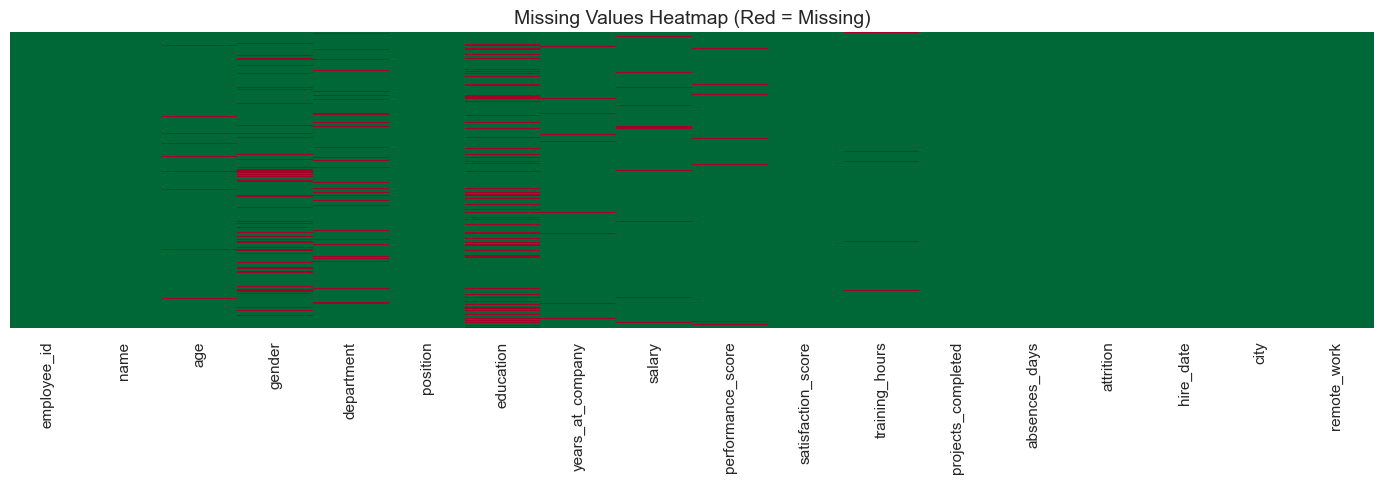

Missing %:
education           22.22
gender              17.39
department          10.39
salary               3.27
performance_score    2.09
age                  1.96
years_at_company     1.31
training_hours       1.31


In [10]:
# Missing value heatmap
plt.figure(figsize=(14, 5))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='RdYlGn_r')
plt.title('Missing Values Heatmap (Red = Missing)', fontsize=14)
plt.tight_layout()
plt.show()

# Missing percentage
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print("Missing %:")
print(missing_pct.to_string())

In [11]:
# Duplicate check
dupes = df_raw.duplicated(subset='employee_id').sum()
print(f"Duplicate employee_id rows: {dupes}")

# Value distributions
print("\nGender unique values:", df_raw['gender'].unique())
print("Department unique values:", df_raw['department'].unique())

Duplicate employee_id rows: 30

Gender unique values: <ArrowStringArray>
['F', 'Male', 'Non-binary', 'Female', 'M', nan]
Length: 6, dtype: str
Department unique values: <ArrowStringArray>
[      'Legal', 'Engineering',          'IT',  'Operations',     'Finance',
   'Marketing',           nan,   'MARKETING',          'HR',         'eng']
Length: 10, dtype: str


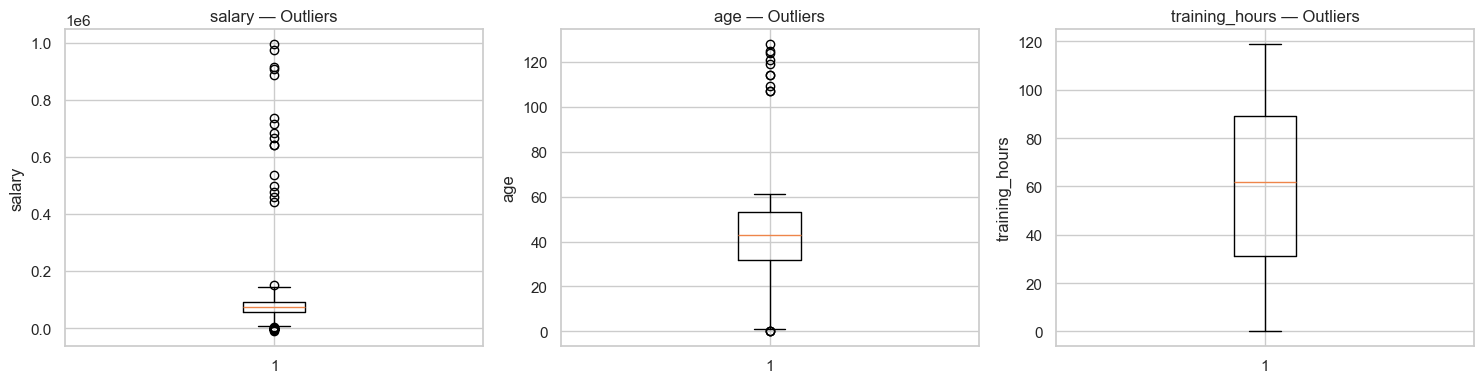

Salary range: -11785.747298459566 to 996051.0723294312
Age range: 0.0 to 128.0


In [12]:
# Outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['salary', 'age', 'training_hours']):
    ax.boxplot(df_raw[col].dropna())
    ax.set_title(f'{col} — Outliers')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

print("Salary range:", df_raw['salary'].min(), "to", df_raw['salary'].max())
print("Age range:", df_raw['age'].min(), "to", df_raw['age'].max())

## 4. Data Cleaning Steps

### 4.1 Remove Duplicates

In [13]:
df = df_raw.copy()
before = len(df)
df = df.drop_duplicates(subset='employee_id')
print(f"Removed {before - len(df)} duplicate rows → {len(df)} records remain")

Removed 30 duplicate rows → 1500 records remain


### 4.2 Standardize Categorical Values

In [14]:
# Department normalization
dept_map = {'eng': 'Engineering', 'MARKETING': 'Marketing'}
df['department'] = df['department'].replace(dept_map)
valid_depts = ['Engineering', 'Marketing', 'HR', 'Finance', 'Operations', 'Legal', 'IT']
df = df[df['department'].isin(valid_depts)]

# Gender normalization
gender_map = {'M': 'Male', 'F': 'Female'}
df['gender'] = df['gender'].replace(gender_map)
valid_genders = ['Male', 'Female', 'Non-binary']
df.loc[~df['gender'].isin(valid_genders), 'gender'] = np.nan

print("Departments:", df['department'].unique())
print("Genders:", df['gender'].unique())

Departments: <ArrowStringArray>
['Legal', 'Engineering', 'IT', 'Operations', 'Finance', 'Marketing', 'HR']
Length: 7, dtype: str
Genders: <ArrowStringArray>
['Female', 'Male', 'Non-binary', nan]
Length: 4, dtype: str


### 4.3 Remove Out-of-Range Values

In [15]:
before = len(df)
df = df[(df['age'] >= 18) & (df['age'] <= 70)]
df = df[(df['salary'] >= 20000) & (df['salary'] <= 350000)]
print(f"Removed {before - len(df)} rows with invalid age/salary → {len(df)} records")

Removed 128 rows with invalid age/salary → 1218 records


### 4.4 Impute Missing Values

In [16]:
# Salary: median by dept+position
df['salary'] = df['salary'].fillna(
    df.groupby(['department','position'])['salary'].transform('median')
)
# Numeric: median/zero
df['age'] = df['age'].fillna(df['age'].median()).astype(int)
df['performance_score'] = df['performance_score'].fillna(df['performance_score'].median())
df['training_hours'] = df['training_hours'].fillna(0)
df['years_at_company'] = df['years_at_company'].fillna(0)
# Categorical: Unknown
df['education'] = df['education'].fillna('Unknown')
df['gender'] = df['gender'].fillna('Unknown')

print("Remaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nAll nulls resolved ✅" if df.isnull().sum().sum() == 0 else "⚠️ Some nulls remain")

Remaining nulls:
Series([], dtype: int64)

All nulls resolved ✅


### 4.5 Type Correction

In [17]:
df['salary'] = df['salary'].round(2)
df['hire_date'] = pd.to_datetime(df['hire_date'])
df['attrition'] = df['attrition'].astype(int)
df['remote_work'] = df['remote_work'].astype(int)
print("Types corrected ✅")
print(df.dtypes)

Types corrected ✅
employee_id                      str
name                             str
age                            int64
gender                           str
department                       str
position                         str
education                        str
years_at_company             float64
salary                       float64
performance_score            float64
satisfaction_score             int64
training_hours               float64
projects_completed             int64
absences_days                  int64
attrition                      int64
hire_date             datetime64[us]
city                             str
remote_work                    int64
dtype: object


## 5. Feature Engineering

In [18]:
# Salary bands
df['salary_band'] = pd.cut(df['salary'],
    bins=[0, 40000, 70000, 100000, 150000, 999999],
    labels=['Entry', 'Lower-Mid', 'Mid', 'Upper-Mid', 'Senior'])

# Tenure groups
df['tenure_group'] = pd.cut(df['years_at_company'],
    bins=[-1, 2, 5, 10, 20],
    labels=['New (<2y)', 'Growing (2-5y)', 'Experienced (5-10y)', 'Veteran (10y+)'])

# Engagement index
df['engagement_index'] = ((df['performance_score'] + df['satisfaction_score']) / 2).round(2)

print("New features created:")
print(df[['salary_band','tenure_group','engagement_index']].head(8))

New features created:
  salary_band         tenure_group  engagement_index
0   Upper-Mid            New (<2y)              4.50
1   Lower-Mid       Veteran (10y+)              4.00
2         Mid            New (<2y)              3.50
3   Lower-Mid       Growing (2-5y)              2.50
4         Mid       Veteran (10y+)              5.00
5   Lower-Mid            New (<2y)              3.00
7         Mid  Experienced (5-10y)              3.00
8   Lower-Mid  Experienced (5-10y)              1.50


## 6. Exploratory Data Analysis (Post-Cleaning)

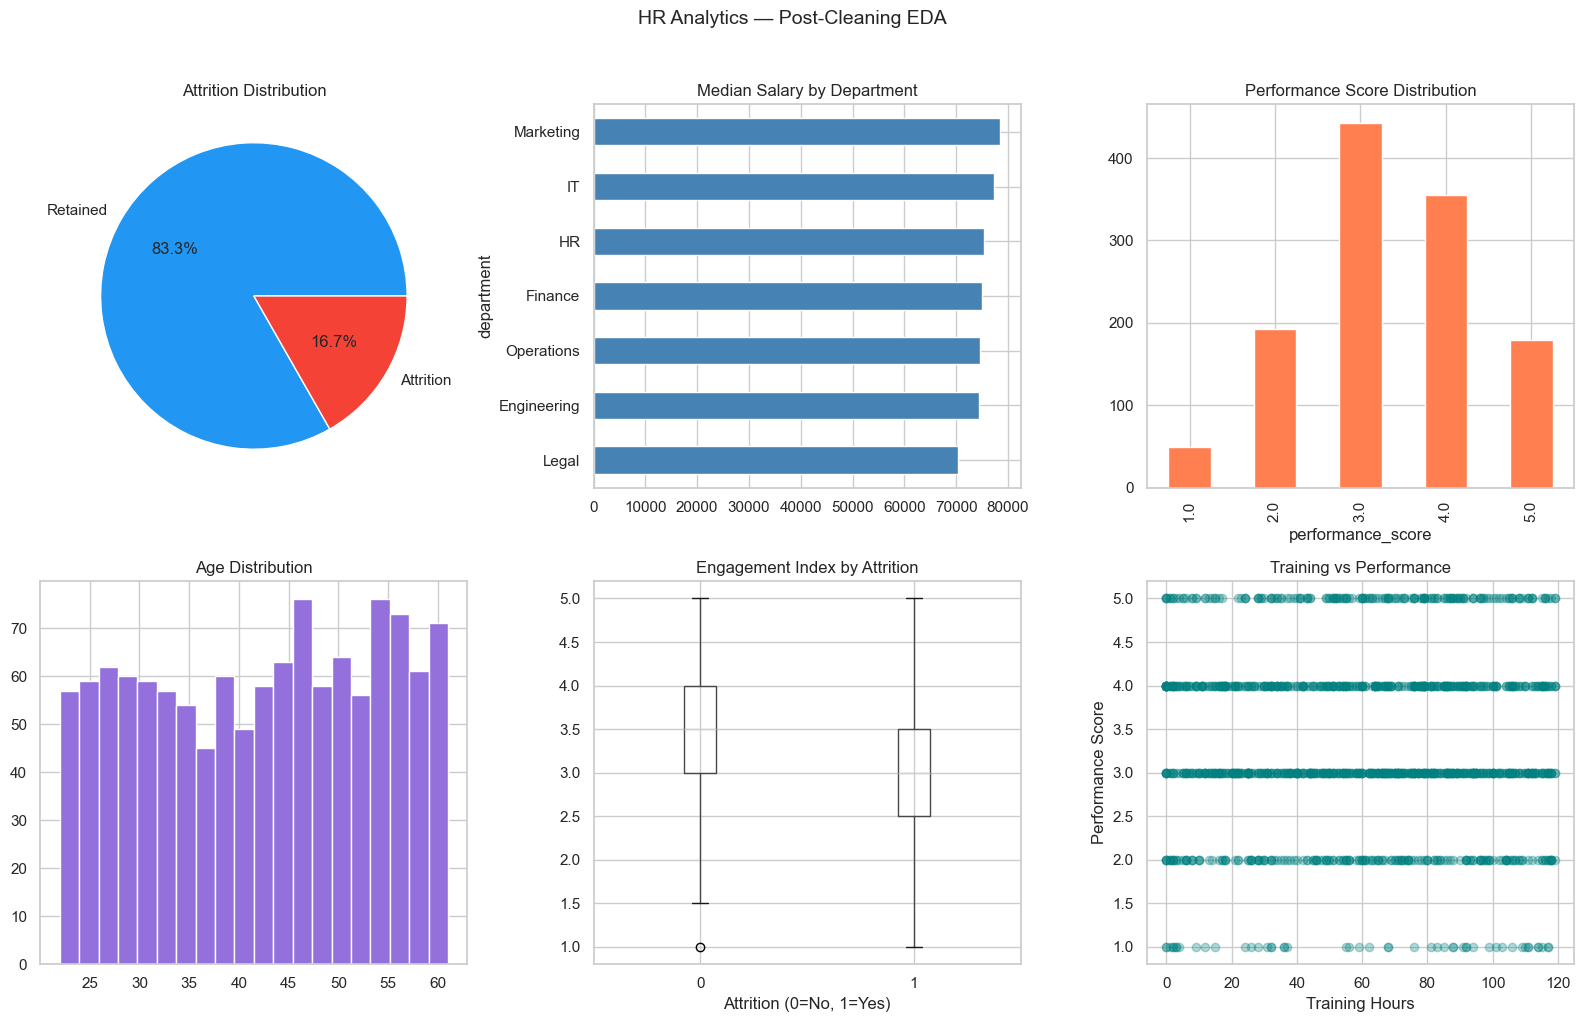

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Attrition distribution
ax = axes[0,0]
counts = df['attrition'].value_counts()
ax.pie(counts, labels=['Retained','Attrition'], autopct='%1.1f%%', colors=['#2196F3','#F44336'])
ax.set_title('Attrition Distribution')

# Salary by department
ax = axes[0,1]
df.groupby('department')['salary'].median().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Median Salary by Department')

# Performance score distribution
ax = axes[0,2]
df['performance_score'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_title('Performance Score Distribution')

# Age distribution
ax = axes[1,0]
ax.hist(df['age'], bins=20, color='mediumpurple', edgecolor='white')
ax.set_title('Age Distribution')

# Engagement index by attrition
ax = axes[1,1]
df.boxplot(column='engagement_index', by='attrition', ax=ax)
ax.set_title('Engagement Index by Attrition')
plt.sca(ax)
plt.xlabel('Attrition (0=No, 1=Yes)')

# Training hours vs performance
ax = axes[1,2]
ax.scatter(df['training_hours'], df['performance_score'], alpha=0.3, color='teal')
ax.set_xlabel('Training Hours')
ax.set_ylabel('Performance Score')
ax.set_title('Training vs Performance')

plt.suptitle('HR Analytics — Post-Cleaning EDA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

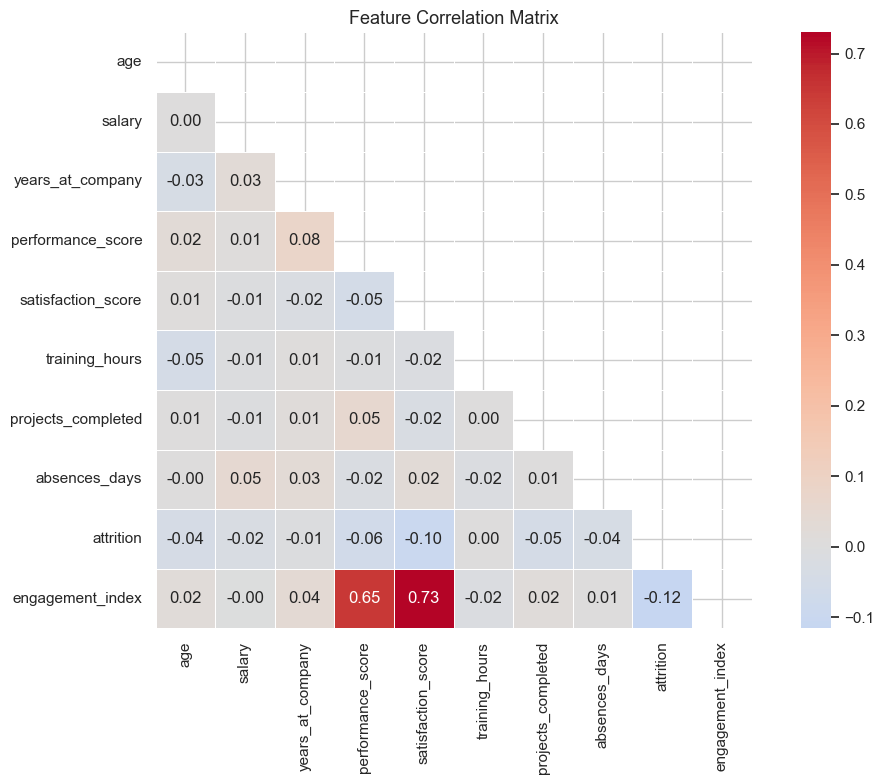

In [20]:
# Correlation heatmap
numeric_cols = ['age','salary','years_at_company','performance_score',
                'satisfaction_score','training_hours','projects_completed',
                'absences_days','attrition','engagement_index']
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Save Clean Dataset

In [21]:
df.to_csv('hr_clean_data.csv', index=False)
print(f"✅ Saved hr_clean_data.csv")
print(f"Final shape: {df.shape}")
print("\nColumn summary:")
display(df.describe(include='all').T[['count','mean','min','max','top','freq']].head(20))

✅ Saved hr_clean_data.csv
Final shape: (1218, 21)

Column summary:


,count,mean,min,max,top,freq
employee_id,1218,NaN,NaN,NaN,EMP0001,1
name,1218,NaN,NaN,NaN,James Crawford,2
age,1218.00,42.23,22.00,61.00,NaN,NaN
gender,1218,NaN,NaN,NaN,Female,413
department,1218,NaN,NaN,NaN,Engineering,277
position,1218,NaN,NaN,NaN,Mid-level,255
education,1218,NaN,NaN,NaN,Bachelor,250
years_at_company,1218.00,9.36,0.00,19.00,NaN,NaN
salary,1218.00,75667.60,20367.58,151548.67,NaN,NaN
performance_score,1218.00,3.35,1.00,5.00,NaN,NaN


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                                  classification_report, confusion_matrix,
                                  mean_squared_error, r2_score, silhouette_score)

In [ ]:
y=df['salary']
cols=df.columns.tolist()
cols.remove('salary')
x=df[cols]
x


In [ ]:

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)


ValueError: could not convert string to float: 'EMP0001'

## 8. Summary

| Step | Action | Result |
|------|--------|--------|
| Duplicates | Removed duplicate employee_id rows | -30 rows |
| Dept/Gender | Standardized typos & aliases | Consistent categories |
| Outliers | Removed invalid ages & salaries | -~80 rows |
| Imputation | Filled NaN with median/group median | 0 nulls remaining |
| Types | Converted dates, booleans | Correct dtypes |
| Features | salary_band, tenure_group, engagement_index | +3 columns |

**Final clean dataset: 1,218 rows × 21 columns** — ready for the Streamlit ML Dashboard.
